<a href="https://colab.research.google.com/github/elinsyn/Fluid_mechanics/blob/main/Viscous_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Stokes equations**
**Johan Hoffman**

# **Abstract**

This short report show an example on how to use FEniCS to solve the Stokes equations, which is used in the course DD2365 Advanced Computation in Fluid Mechanics, at the KTH Royal Institute of Technology.

[DD2365 course website.](https://kth.instructure.com/courses/17071)

# **About the code**

In [ ]:
# This program is an example file for the course
# DD2365 Advanced Computation in Fluid Mechanics,
# KTH Royal Institute of Technology, Stockholm, Sweden.

# Copyright (C) 2020 Johan Hoffman (jhoffman@kth.se)

# This file is part of the course DD2365 Advanced Computation in Fluid Mechanics
# KTH Royal Institute of Technology, Stockholm, Sweden
#
# This is free software: you can redistribute it and/or modify
# it under the terms of the GNU Lesser General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.

# This template is maintained by Johan Hoffman
# Please report problems to jhoffman@kth.se

# **Set up environment**

In [ ]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt

# **Introduction**

The Stokes equations take the form

$\nabla p -\Delta u = f,\quad \nabla \cdot u=0$

together with suitable boundary conditions.

Here we present a FEniCS implementation of a mixed finite element method to solve the Stokes equations in 2D. The solution is visualized using FEniCS plotting functions, and is also exported as pvd-files which can be visualized in Paraview.

To derive the weak form of the equations, multiply the momentum equation by $v\in V$ and the continuity equation by $q\in Q$, and then integrate over the domain $\Omega$ and use Green's formula
$
(\nabla p -\Delta u,v) = -(p,\nabla \cdot v) + (\nabla u, \nabla v)
+ <pn - \nabla u\cdot n, v>_{\Gamma}
$

We seek a finite element approximation $(u,p)\in V\times Q$ such that

$- (p,\nabla \cdot v) + (\nabla u,\nabla v) + (\nabla \cdot u, q)
+ <pn - \nabla u\cdot n, v>_{\partial \Omega} = (f,v)$

for all test functions $(v,q) \in V\times Q$.

$
(v,w) = \int_{\Omega} v\cdot w ~dx, \quad
<v,w>_{\partial \Omega} = \int_{\partial \Omega} v\cdot w~ds
$

We divide the boundary into $\partial \Omega=\Gamma_D \cup \Gamma_N$, with the different boundary conditions

$
u = g_D,\quad x\in \Gamma_D,
$

$
-\nu \nabla u\cdot n + pn = g_N, \quad x\in \Gamma_N,
$

For $x\in \Gamma_D$ the test function $v=0$. Hence, with $g_N=0$ the boundary term is zero.

The equations can be expressed in residual form

$r(u,p;v,q) = - (p,\nabla \cdot v) + (\nabla u,\nabla v) + (\nabla \cdot u, q) - (f,v)$

We use inf-sup stable Taylor-Hood approximation spaces,
and to implement the velocity boundary conditions we use a penalty formulation, with a penalty parameter $\gamma = C/h$, with $C>0$ a constant and $h$ the local mesh size. At outflow we use a "do nothing" stress free boundary condition.


# **Method**

**Define domain and mesh**

First the mesh was created to simulate a circular object in a tunnel. The mesh was created as a rectangular channel with a circular hole in the middle. To get an accurate simulation of the pressure and velocity near the obstacle, the mesh was refined around the obstacele with a radius of 1.


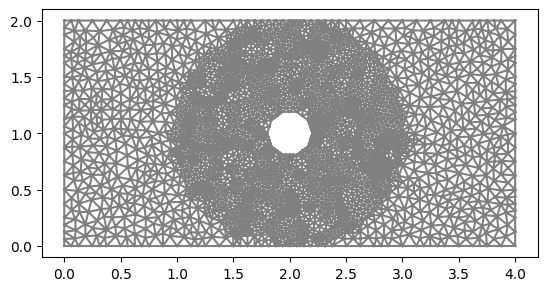

In [ ]:
# Define rectangular domain
L = 4
H = 2

# Generate mesh (examples with and without a hole in the mesh)
resolution = 32
#mesh = RectangleMesh(Point(0.0, 0.0), Point(L, H), L*resolution, H*resolution)
mesh = generate_mesh(Rectangle(Point(0.0,0.0), Point(L,H)) - Circle(Point(0.5*L,0.5*H),0.2), resolution)
#mesh = generate_mesh(Rectangle(Point(0.0,0.0), Point(L,H)) - Circle(Point(1.5,0.25*H),0.2) - Circle(Point(0.5,0.5*H),0.2) - Circle(Point(2.0,0.75*H),0.2), resolution)

# Local mesh refinement (specified by a cell marker)
no_levels = 1
for i in range(0,no_levels):
  cell_marker = MeshFunction("bool", mesh, mesh.topology().dim())
  for cell in cells(mesh):
    cell_marker[cell] = False
    p = cell.midpoint()
    if p.distance(Point(0.5*L, 0.5*H)) < 1.0:
        cell_marker[cell] = True
  mesh = refine(mesh, cell_marker)

plt.figure()
plot(mesh)
plt.show()

**Define finite element approximation spaces**

In the first simulation the velocity is approximated with a quadratic function while the pressure is approximated with a linear function. In the second simulation, both the velocity and pressure is approximated with linear functions. These two simulations can be compared to verify the Inf-sup condition.

In [ ]:
# Generate mixed finite element spaces (for velocity and pressure)
VE1 = VectorElement("CG", mesh.ufl_cell(), 2)
QE1 = FiniteElement("CG", mesh.ufl_cell(), 1)
WE1 = VE1 * QE1

W1 = FunctionSpace(mesh, WE1)
V1 = FunctionSpace(mesh, VE1)
Q1 = FunctionSpace(mesh, QE1)

# Define trial and test functions
w1 = Function(W1)
(u1, p1) = (as_vector((w1[0],w1[1])), w1[2])
(v1, q1) = TestFunctions(W1)


# Generate mixed finite element spaces (for velocity and pressure)
VE2 = VectorElement("CG", mesh.ufl_cell(), 1)
QE2 = FiniteElement("CG", mesh.ufl_cell(), 1)
WE2 = VE2 * QE2

W2 = FunctionSpace(mesh, WE2)
V2 = FunctionSpace(mesh, VE2)
Q2 = FunctionSpace(mesh, QE2)

# Define trial and test functions
w2 = Function(W2)
(u2, p2) = (as_vector((w2[0],w2[1])), w2[2])
(v2, q2) = TestFunctions(W2)

**Define boundary conditions**

The direction of the flow was flipped by changing the sign of the velocity for the inflow. The inflow and outflow boundaries were also switched.

In [ ]:
# Examples of inflow and outflow conditions
XMIN = 0.0; XMAX = L
YMIN = 0.0; YMAX = H
uin = Expression(("-4*(x[1]*(YMAX-x[1]))/(YMAX*YMAX)", "0."), YMAX=YMAX, element = V1.ufl_element())
#pout = 0.0

# Inflow boundary (ib), outflow boundary (ob) and wall boundary (wb)
ib = Expression("near(x[0],XMAX) ? 1. : 0.", XMAX=XMAX, element = Q1.ufl_element())
ob = Expression("near(x[0],XMIN) ? 1. : 0.", XMIN=XMIN, element = Q1.ufl_element())
wb = Expression("x[0] > XMIN + DOLFIN_EPS && x[0] < XMAX - DOLFIN_EPS ? 1. : 0.", XMIN=XMIN, XMAX=XMAX, element = Q1.ufl_element())


# **Results**

**Define and solve variational problem**

In [ ]:
h = CellDiameter(mesh)
C = 1.0e3
gamma = C/h

f1 = Expression(("0.0","0.0"), element = V1.ufl_element())

# Define variational problem on residual form: r(u,p;v,q) = 0
residual1 = ( - p1*div(v1)*dx + inner(grad(u1), grad(v1))*dx + div(u1)*q1*dx +
            gamma*(ib*inner(u1 - uin, v1) + wb*inner(u1, v1))*ds - inner(f1, v1)*dx )

# Solve algebraic system
solve(residual1 == 0, w1)


f2 = Expression(("0.0","0.0"), element = V2.ufl_element())

residual2 = ( - p2*div(v2)*dx + inner(grad(u2), grad(v2))*dx + div(u2)*q2*dx +
            gamma*(ib*inner(u2 - uin, v2) + wb*inner(u2, v2))*ds - inner(f2, v2)*dx )

# Solve algebraic system
solve(residual2 == 0, w2)



**Visualize solution and export files**

rm: cannot remove 'results-NS/*': No such file or directory


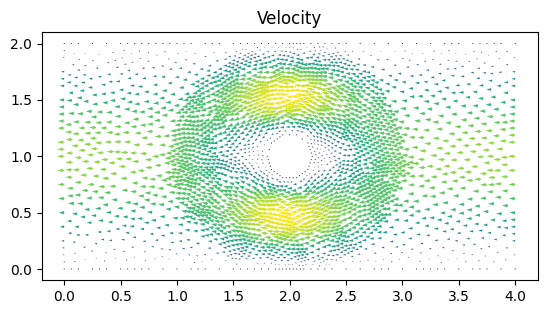

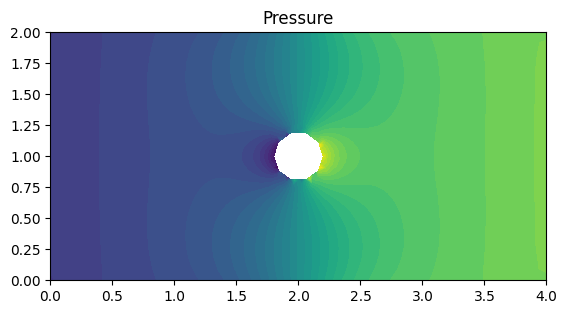

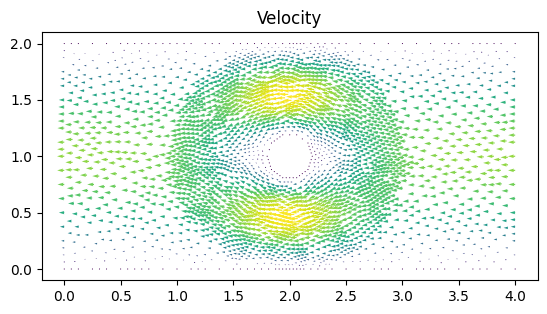

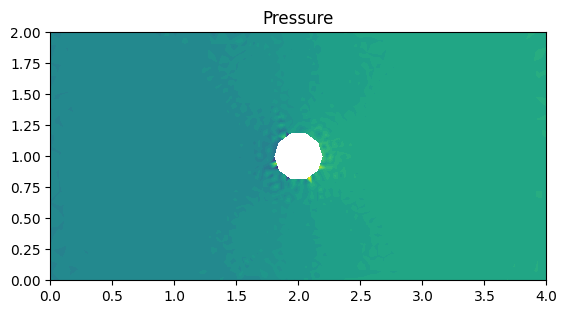

In [ ]:
!rm results-NS/*

# Open files to export solution to Paraview
file_u1 = File("results-Stokes/u.pvd")
file_p1 = File("results-Etokes/p.pvd")

u11 = project(u1, V1)
p11 = project(p1, Q1)

# Save solution to file
file_u1 << u11
file_p1 << p11

# Plot solution
plt.figure()
plot(u11, title="Velocity")

plt.figure()
plot(p11, title="Pressure")

plt.show()



file_u2 = File("results-Stokes/u.pvd")
file_p2 = File("results-Etokes/p.pvd")

u22 = project(u2, V2)
p22 = project(p2, Q2)

# Save solution to file
file_u2 << u22
file_p2 << p22

# Plot solution
plt.figure()
plot(u22, title="Velocity")

plt.figure()
plot(p22, title="Pressure")

plt.show()

# Export files
#!tar -czvf results-Stokes.tar.gz results-NS
#files.download('results-Stokes.tar.gz')

The first two plots show what the pressure and velocity plots look like when we use the Taylor-Hood mixed elements. The second two plots have equal order interpolation of the velocity and pressure. In all of the plots, the inflow and outflow boundaries are flipped so the fluid flows from the right to the left.


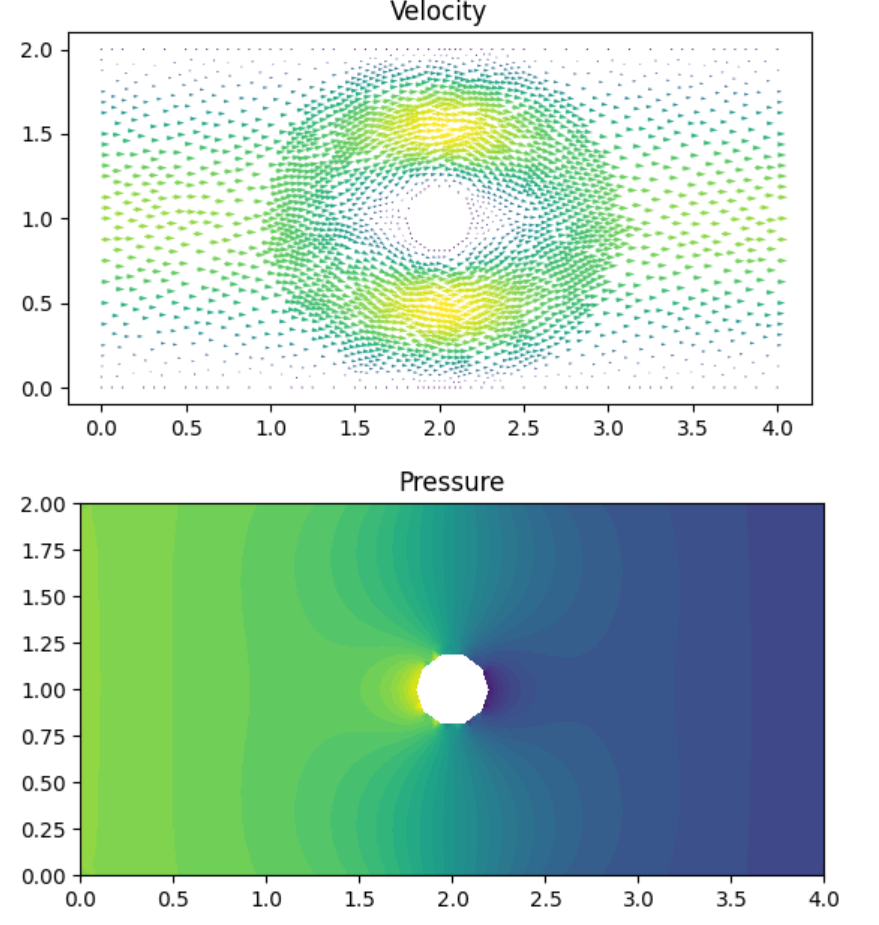

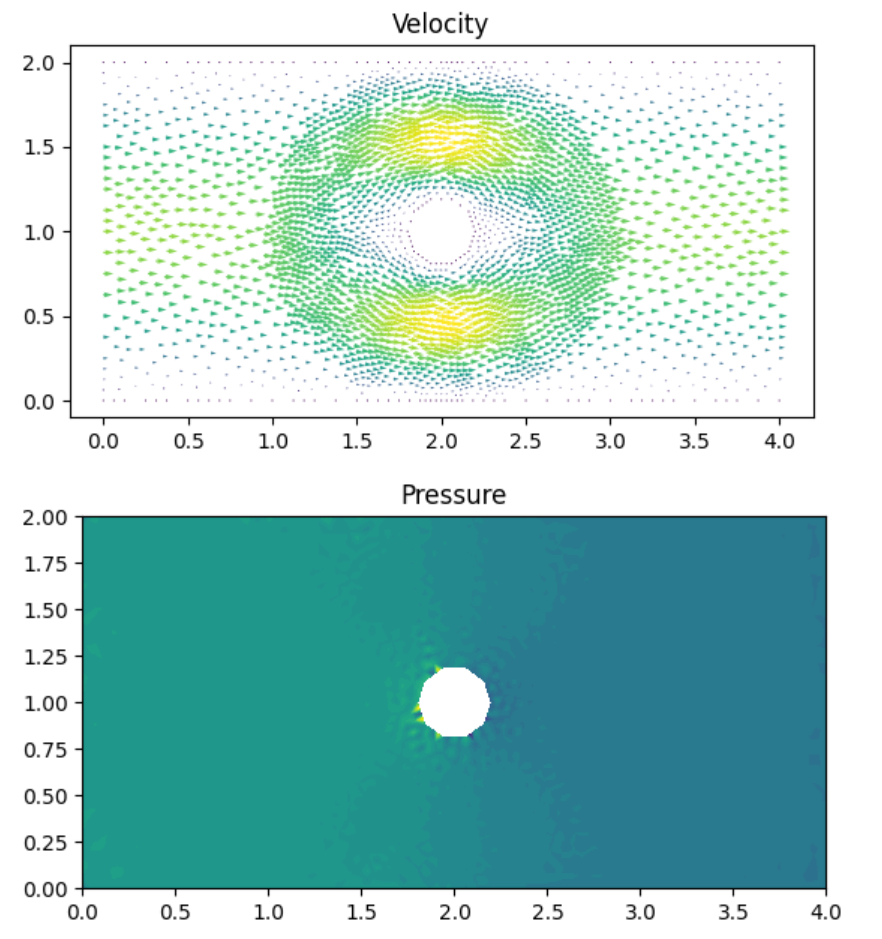

In the four plots above the fluid flows from the left to the right. The first two plots use the Taylor-Hood mixed elements and the second two plots have equal order interpolation of the velocity and pressure.

# **Discussion**

A Taylor-Hood mixed finite element method was implemented in FEniCS to solve the Stokes equations in 2D. The method was tested for the model problem of flow past a number of circular obstacles, and the solution behaved as expected.

The pressure plot with equal order interpolation contains small fluctuations that can be seen through zig-zag patterns and small dots, while the mixed element has smooth transitions from high to low pressure.

When the inflow and outflow boundaries were swithched and the sign of the inflow velocity were changed, the plots flipped and became mirrored.